# ERCOT Spark Spread Analysis — Texas Gas Hub Prices
Uses geographically matched gas hub prices instead of Henry Hub proxy.

| ERCOT Hub | Gas Hub | Ticker |
|-----------|---------|--------|
| HB_WEST | Waha | NGTXOASI BNGC |
| HB_HOUSTON | Houston Ship Channel | NGGCHOUS BNGC |
| HB_NORTH | Katy | NTGSTXKA BNGC |
| HB_SOUTH | Agua Dulce (Henry Hub fallback for gaps) | NGTXAGDU BNGC |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

CCGT_HR   = 7.0
PEAKER_HR = 10.0

## 1. Load Texas Gas Hub Prices

In [2]:
def load_gas_sheet(sheet_name):
    df = pd.read_excel(
        'data/teas_nat_gas.xlsx',
        sheet_name=sheet_name,
        skiprows=6,
        header=None,
        names=['Date', 'PX_LAST', 'CHG_PCT_1D']
    )
    df = df[pd.to_numeric(df['Date'], errors='coerce').notna()].copy()
    df['Date'] = pd.to_datetime(df['Date'].astype(int), unit='D', origin='1899-12-30')
    df = df[['Date', 'PX_LAST']].dropna().sort_values('Date').reset_index(drop=True)
    df = df[df['Date'] >= '2025-01-01']
    return df

waha = load_gas_sheet('Waha').rename(columns={'PX_LAST': 'Waha'})
hsc  = load_gas_sheet('HSC').rename(columns={'PX_LAST': 'HSC'})
katy = load_gas_sheet('Katy').rename(columns={'PX_LAST': 'Katy'})
agua = load_gas_sheet('Agua Dulce').rename(columns={'PX_LAST': 'AguaDulce'})

for name, df in [('Waha', waha), ('HSC', hsc), ('Katy', katy), ('Agua Dulce', agua)]:
    print(f"{name}: {df['Date'].min().date()} to {df['Date'].max().date()}, {len(df)} rows")

Waha: 2025-01-02 to 2025-12-31, 247 rows
HSC: 2025-01-02 to 2025-12-31, 247 rows
Katy: 2025-01-02 to 2025-12-31, 247 rows
Agua Dulce: 2025-01-07 to 2025-06-11, 36 rows


## 2. Load Henry Hub (Agua Dulce Fallback)

In [3]:
hh = pd.read_csv('data/Henry_Hub_Natural_Gas_Spot_Price.csv', skiprows=4)
hh.columns = ['Date', 'HH_Price']
hh['Date'] = pd.to_datetime(hh['Date'])
hh = hh.sort_values('Date').reset_index(drop=True)
hh = hh[hh['Date'] >= '2025-01-01']
print(f"Henry Hub: {hh['Date'].min().date()} to {hh['Date'].max().date()}, {len(hh)} rows")

Henry Hub: 2025-01-02 to 2025-12-17, 240 rows


## 3. Build Agua Dulce with Henry Hub Fallback

In [4]:
# Merge Agua Dulce with Henry Hub on date; fill gaps with Henry Hub
south_gas = hh.merge(agua, on='Date', how='left')
south_gas['South_Gas'] = south_gas['AguaDulce'].combine_first(south_gas['HH_Price'])
south_gas['South_Source'] = np.where(south_gas['AguaDulce'].notna(), 'Agua Dulce', 'Henry Hub')

print("South Gas Price Source Breakdown:")
print(south_gas['South_Source'].value_counts())
south_gas[['Date', 'South_Gas', 'South_Source']].tail(5)

South Gas Price Source Breakdown:
South_Source
Henry Hub     204
Agua Dulce     36
Name: count, dtype: int64


,Date,South_Gas,South_Source
235,2025-12-11,4.35,Henry Hub
236,2025-12-12,4.07,Henry Hub
237,2025-12-15,3.9,Henry Hub
238,2025-12-16,3.58,Henry Hub
239,2025-12-17,3.66,Henry Hub


## 4. Load ERCOT DAM Hub Prices

In [5]:
ercot_file = 'data/rpt.00013060.0000000000000000.DAMLZHBSPP_2025.xlsx'
all_sheets = pd.read_excel(ercot_file, sheet_name=None)
ercot_df = pd.concat(all_sheets.values(), ignore_index=True)

ercot_df['Delivery Date'] = pd.to_datetime(ercot_df['Delivery Date'])

target_hubs = ['HB_HOUSTON', 'HB_NORTH', 'HB_SOUTH', 'HB_WEST']
hub_df = ercot_df[ercot_df['Settlement Point'].isin(target_hubs)].copy()

daily_elec = hub_df.groupby(['Settlement Point', pd.Grouper(key='Delivery Date', freq='D')]).agg(
    Elec_Mean=('Settlement Point Price', 'mean'),
    Elec_Min=('Settlement Point Price', 'min'),
    Elec_Max=('Settlement Point Price', 'max'),
    Elec_Std=('Settlement Point Price', 'std'),
).reset_index()
daily_elec.columns = ['Hub', 'Date', 'Elec_Mean', 'Elec_Min', 'Elec_Max', 'Elec_Std']

print(f"ERCOT: {daily_elec['Date'].min().date()} to {daily_elec['Date'].max().date()}")
print(daily_elec.groupby('Hub').size())

ERCOT: 2025-01-01 to 2025-12-13
Hub
HB_HOUSTON    347
HB_NORTH      347
HB_SOUTH      347
HB_WEST       347
dtype: int64


## 5. Build Per-Hub Analysis DataFrames

In [6]:
def build_hub_df(ercot_hub, gas_df, gas_col):
    elec = daily_elec[daily_elec['Hub'] == ercot_hub].copy()
    merged = elec.merge(gas_df[['Date', gas_col]], on='Date', how='inner')
    merged = merged.rename(columns={gas_col: 'Gas_Price'})
    merged['Implied_HR']        = merged['Elec_Mean'] / merged['Gas_Price']
    merged['Spark_CCGT']        = merged['Elec_Mean'] - (merged['Gas_Price'] * CCGT_HR)
    merged['Spark_Peaker']      = merged['Elec_Mean'] - (merged['Gas_Price'] * PEAKER_HR)
    return merged

hub_west    = build_hub_df('HB_WEST',    waha,      'Waha')
hub_houston = build_hub_df('HB_HOUSTON', hsc,       'HSC')
hub_north   = build_hub_df('HB_NORTH',  katy,      'Katy')
hub_south   = build_hub_df('HB_SOUTH',  south_gas, 'South_Gas')

all_hubs = {
    'HB_WEST (Waha)':          hub_west,
    'HB_HOUSTON (HSC)':        hub_houston,
    'HB_NORTH (Katy)':         hub_north,
    'HB_SOUTH (Agua Dulce/HH)': hub_south,
}

for label, df in all_hubs.items():
    print(f"\n{label}: {len(df)} overlapping days ({df['Date'].min().date()} to {df['Date'].max().date()})")


HB_WEST (Waha): 236 overlapping days (2025-01-02 to 2025-12-12)

HB_HOUSTON (HSC): 236 overlapping days (2025-01-02 to 2025-12-12)

HB_NORTH (Katy): 236 overlapping days (2025-01-02 to 2025-12-12)

HB_SOUTH (Agua Dulce/HH): 237 overlapping days (2025-01-02 to 2025-12-12)


## 6. Summary Statistics

In [7]:
print(f"{'Hub':<30} {'Gas Mean':>10} {'Elec Mean':>10} {'Impl HR':>8} {'CCGT SS':>10} {'Peaker SS':>10} {'CCGT +%':>8} {'Peaker +%':>10}")
print('-' * 100)

for label, df in all_hubs.items():
    if len(df) == 0:
        print(f"{label:<30} {'NO DATA':>10}")
        continue
    ccgt_pct   = 100 * (df['Spark_CCGT'] > 0).mean()
    peaker_pct = 100 * (df['Spark_Peaker'] > 0).mean()
    print(f"{label:<30} "
          f"${df['Gas_Price'].mean():>9.2f} "
          f"${df['Elec_Mean'].mean():>9.2f} "
          f"{df['Implied_HR'].median():>8.2f} "
          f"${df['Spark_CCGT'].mean():>9.2f} "
          f"${df['Spark_Peaker'].mean():>9.2f} "
          f"{ccgt_pct:>7.1f}% "
          f"{peaker_pct:>9.1f}%")

Hub                              Gas Mean  Elec Mean  Impl HR    CCGT SS  Peaker SS  CCGT +%  Peaker +%
----------------------------------------------------------------------------------------------------
HB_WEST (Waha)                 $     0.76 $    36.20    19.43 $    30.87 $    28.58    97.0%      95.3%
HB_HOUSTON (HSC)               $     3.10 $    36.94    11.62 $    15.22 $     5.91    97.0%      72.5%
HB_NORTH (Katy)                $     3.07 $    35.02    10.94 $    13.51 $     4.30    93.2%      65.3%
HB_SOUTH (Agua Dulce/HH)       $     3.42 $    35.03     9.97 $    11.12 $     0.87    85.7%      49.8%


## 7. Gas Price Comparison Across Hubs

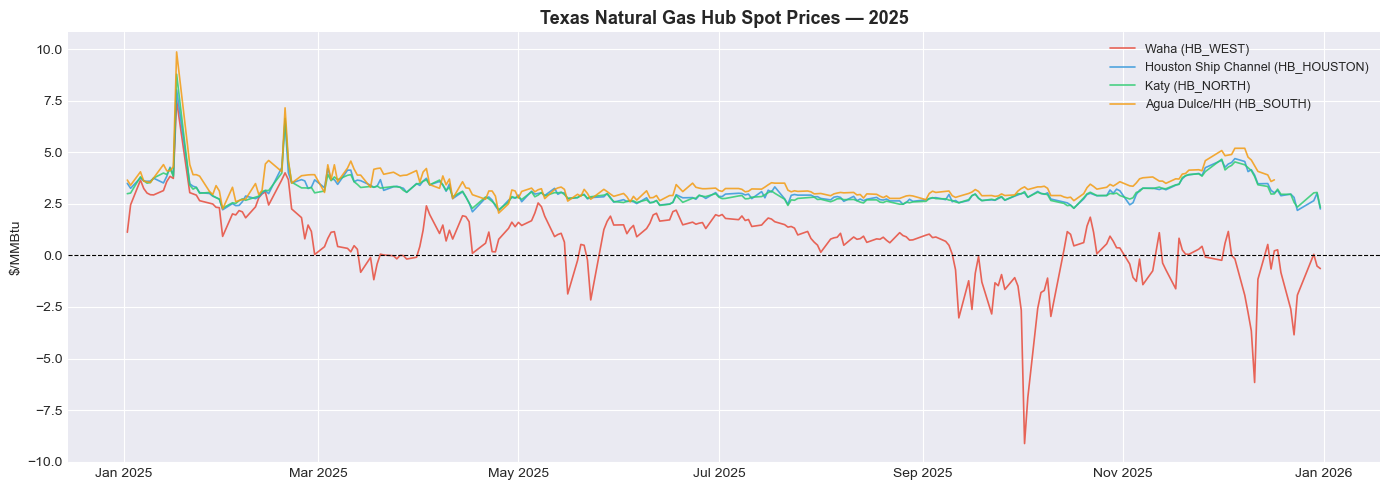

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

colors = {'Waha': '#e74c3c', 'HSC': '#3498db', 'Katy': '#2ecc71', 'South_Gas': '#f39c12'}
labels = {'Waha': 'Waha (HB_WEST)', 'HSC': 'Houston Ship Channel (HB_HOUSTON)',
          'Katy': 'Katy (HB_NORTH)', 'South_Gas': 'Agua Dulce/HH (HB_SOUTH)'}

for gas_df, col in [(waha, 'Waha'), (hsc, 'HSC'), (katy, 'Katy'), (south_gas, 'South_Gas')]:
    ax.plot(gas_df['Date'], gas_df[col], label=labels[col], color=colors[col], linewidth=1.2, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Texas Natural Gas Hub Spot Prices — 2025', fontsize=13, fontweight='bold')
ax.set_ylabel('$/MMBtu')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

## 8. Implied Heat Rate by Hub

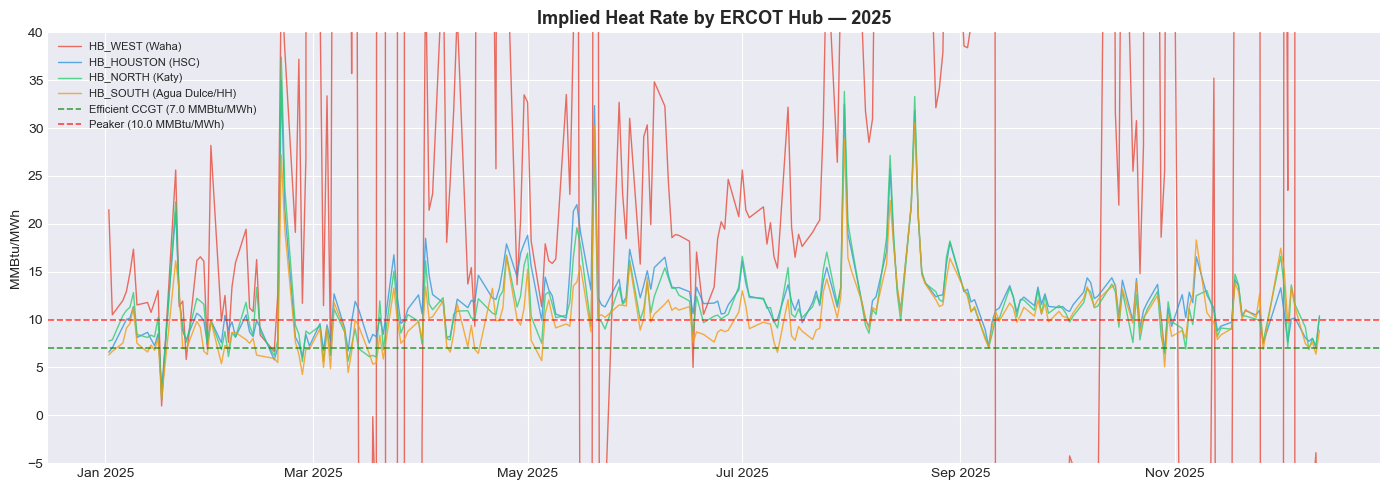

In [9]:
colors_hub = {
    'HB_WEST (Waha)': '#e74c3c',
    'HB_HOUSTON (HSC)': '#3498db',
    'HB_NORTH (Katy)': '#2ecc71',
    'HB_SOUTH (Agua Dulce/HH)': '#f39c12'
}

fig, ax = plt.subplots(figsize=(14, 5))

for label, df in all_hubs.items():
    if len(df) == 0: continue
    ax.plot(df['Date'], df['Implied_HR'], label=label, color=colors_hub[label], linewidth=1, alpha=0.8)

ax.axhline(CCGT_HR,   color='green', linestyle='--', linewidth=1.2, alpha=0.7, label=f'Efficient CCGT ({CCGT_HR} MMBtu/MWh)')
ax.axhline(PEAKER_HR, color='red',   linestyle='--', linewidth=1.2, alpha=0.7, label=f'Peaker ({PEAKER_HR} MMBtu/MWh)')
ax.set_ylim(-5, 40)
ax.set_title('Implied Heat Rate by ERCOT Hub — 2025', fontsize=13, fontweight='bold')
ax.set_ylabel('MMBtu/MWh')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

## 9. Spark Spreads — CCGT & Peaker (Per Hub)

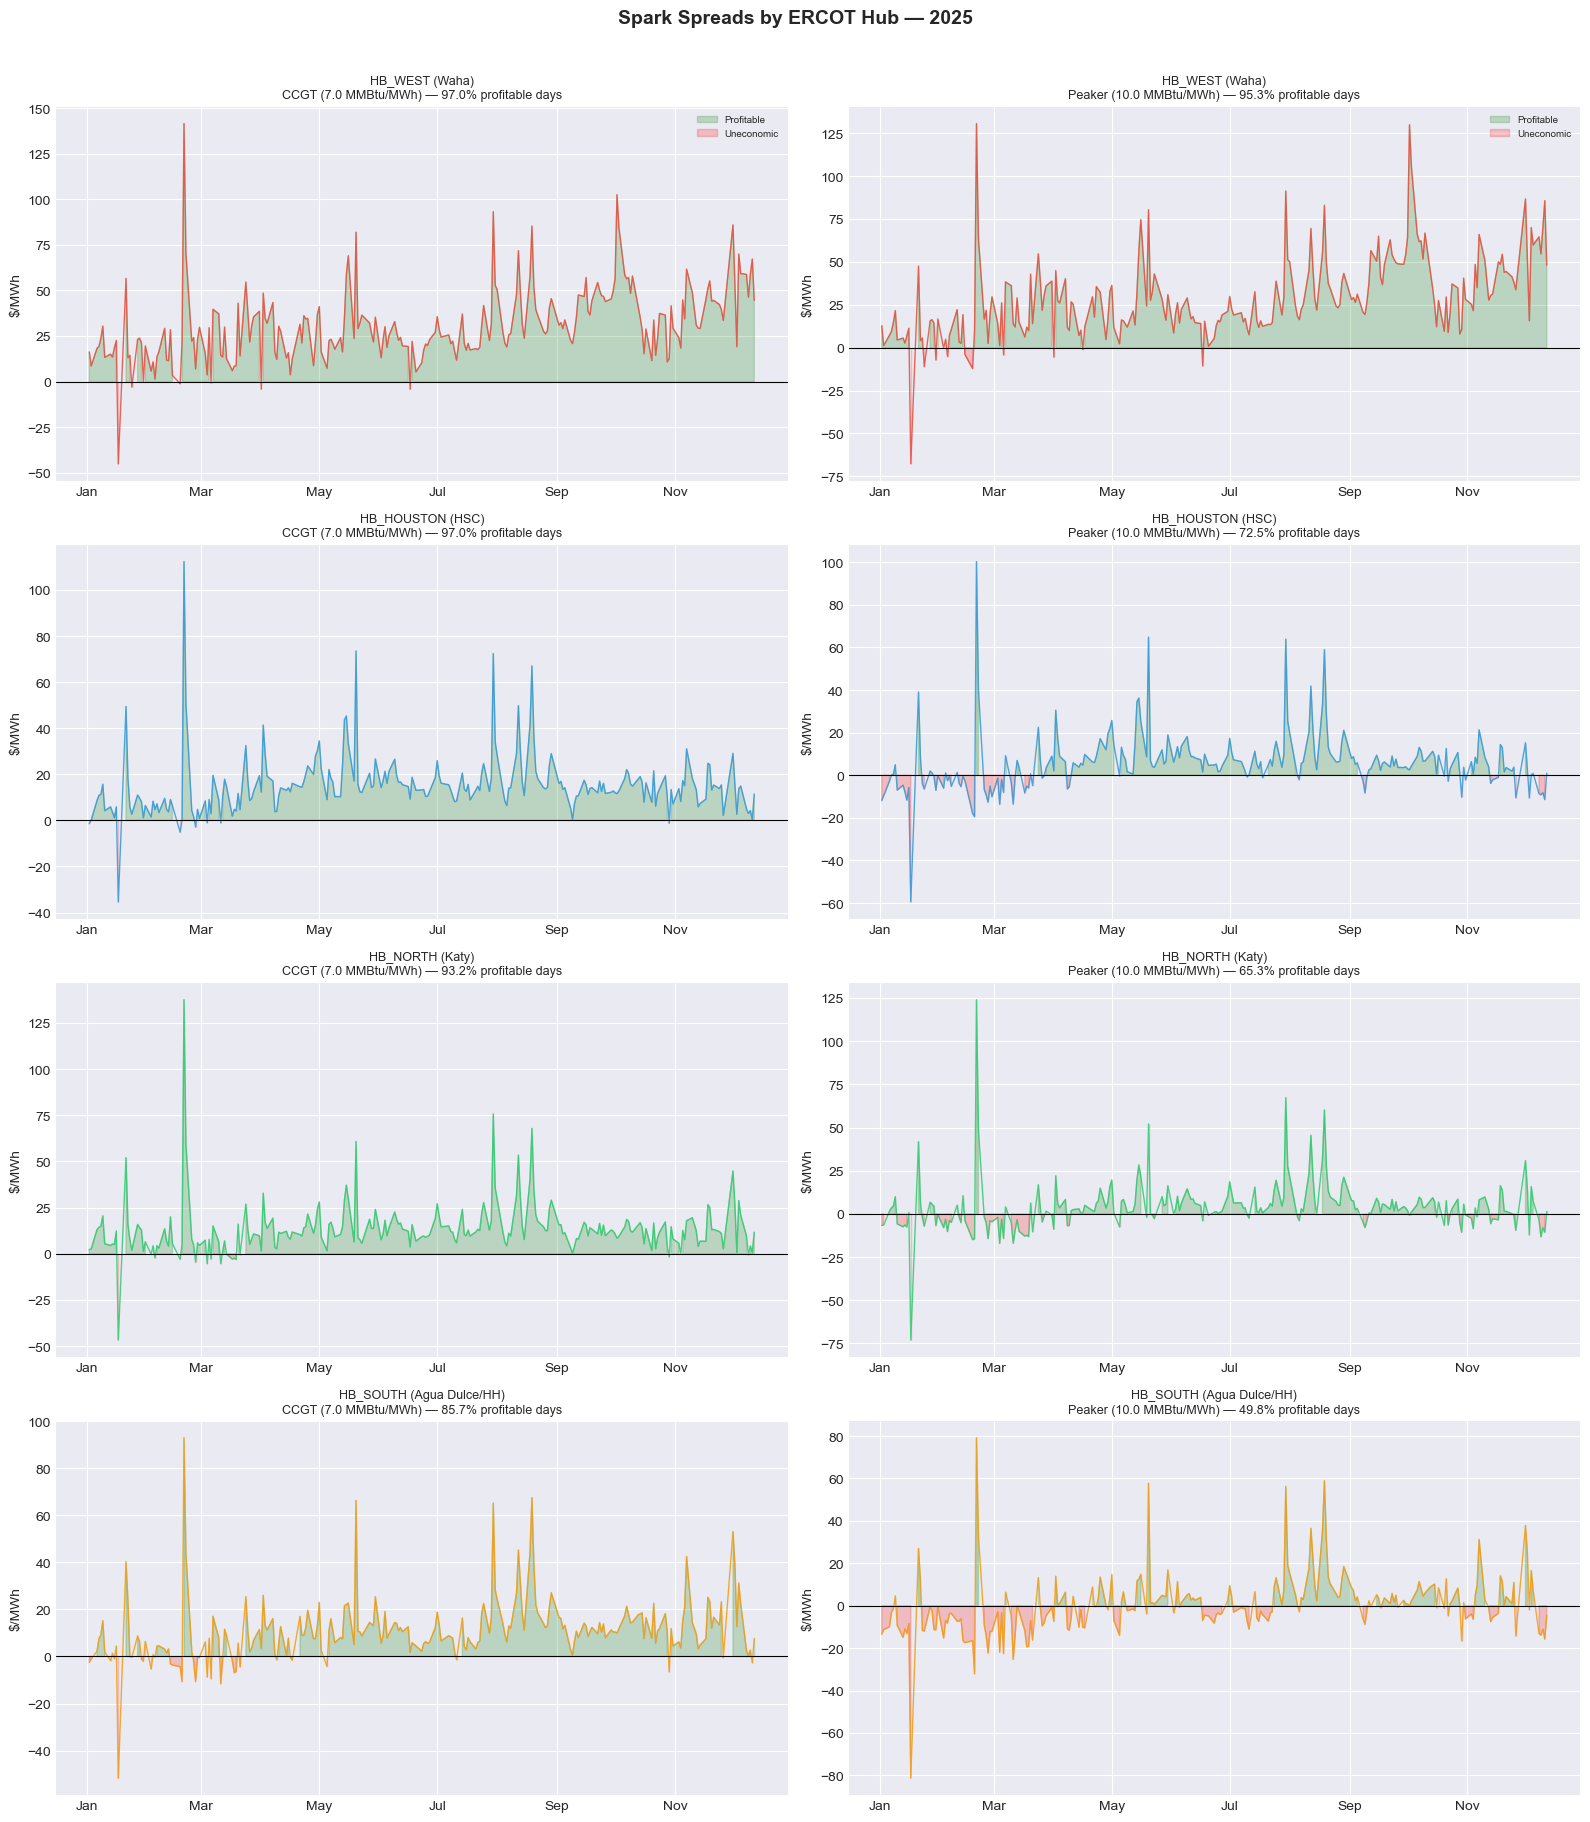

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18), sharex=False)
fig.suptitle('Spark Spreads by ERCOT Hub — 2025', fontsize=14, fontweight='bold', y=1.01)

for i, (label, df) in enumerate(all_hubs.items()):
    color = list(colors_hub.values())[i]
    if len(df) == 0:
        axes[i, 0].text(0.5, 0.5, 'No Data', ha='center', va='center')
        axes[i, 1].text(0.5, 0.5, 'No Data', ha='center', va='center')
        continue

    for j, (col, hr_label) in enumerate([('Spark_CCGT', f'CCGT ({CCGT_HR} MMBtu/MWh)'),
                                          ('Spark_Peaker', f'Peaker ({PEAKER_HR} MMBtu/MWh)')]):
        ax = axes[i, j]
        dates = df['Date'].values
        vals  = df[col].astype(float).values
        ax.plot(dates, vals, color=color, linewidth=1, alpha=0.85)
        ax.fill_between(dates, vals, 0, where=vals >= 0, alpha=0.2, color='green', label='Profitable')
        ax.fill_between(dates, vals, 0, where=vals <  0, alpha=0.2, color='red',   label='Uneconomic')
        ax.axhline(0, color='black', linewidth=0.8)
        pct = 100 * (vals > 0).mean()
        ax.set_title(f'{label}\n{hr_label} — {pct:.1f}% profitable days', fontsize=9)
        ax.set_ylabel('$/MWh')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        if i == 0: ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 10. Basis vs Henry Hub

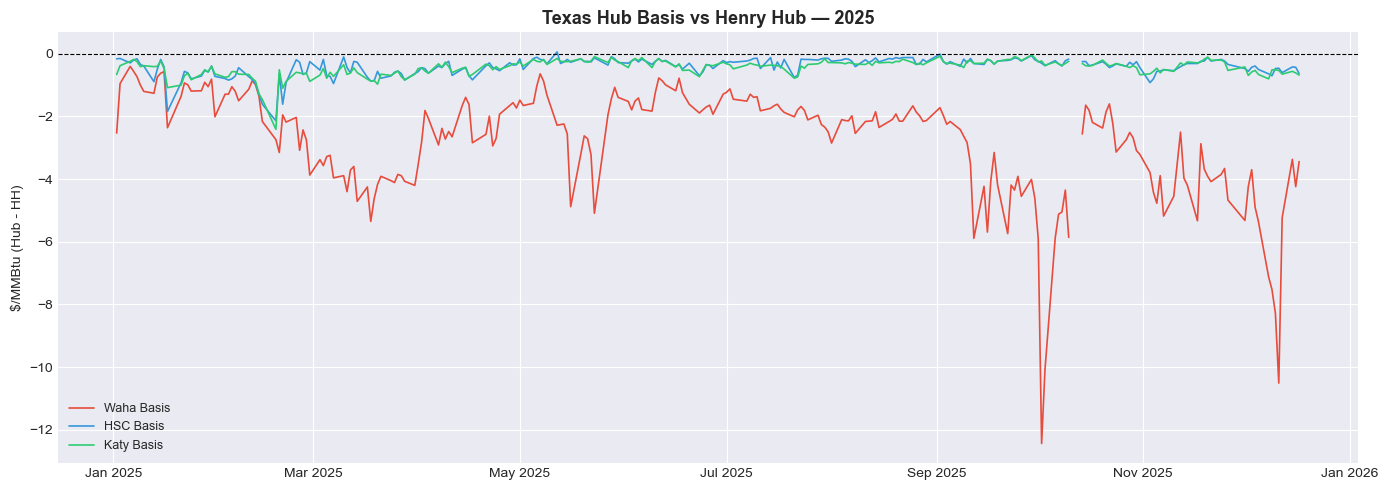


Mean Basis vs Henry Hub ($/MMBtu):
  Waha: $-2.755
  HSC:  $-0.404
  Katy: $-0.436


In [11]:
# Merge all gas hubs with Henry Hub to show basis differentials
basis = hh.copy()
basis = basis.merge(waha, on='Date', how='left')
basis = basis.merge(hsc,  on='Date', how='left')
basis = basis.merge(katy, on='Date', how='left')

basis['Waha_Basis'] = basis['Waha'] - basis['HH_Price']
basis['HSC_Basis']  = basis['HSC']  - basis['HH_Price']
basis['Katy_Basis'] = basis['Katy'] - basis['HH_Price']

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(basis['Date'], basis['Waha_Basis'], label='Waha Basis', color='#e74c3c', linewidth=1.2)
ax.plot(basis['Date'], basis['HSC_Basis'],  label='HSC Basis',  color='#3498db', linewidth=1.2)
ax.plot(basis['Date'], basis['Katy_Basis'], label='Katy Basis', color='#2ecc71', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax.set_title('Texas Hub Basis vs Henry Hub — 2025', fontsize=13, fontweight='bold')
ax.set_ylabel('$/MMBtu (Hub - HH)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

print("\nMean Basis vs Henry Hub ($/MMBtu):")
print(f"  Waha: ${basis['Waha_Basis'].mean():.3f}")
print(f"  HSC:  ${basis['HSC_Basis'].mean():.3f}")
print(f"  Katy: ${basis['Katy_Basis'].mean():.3f}")